# Funding options and award evidence, focus cities — oef / br-city-finance-feasibility, release v1

Deepens the pilot action profiles for an 8-city focus set by attaching the awards evidence layer: real, verified awarded/selected records from the br-climate-awards compile, surfaced as "these options are available" context beside the funding-gap bucket. Evidence sits beside the score and never feeds it (the Chile precedent's rule, kept). Rules: `data/pilot/action-profile-method.md`, evidence section.

In [1]:
# Parameters
PROFILES_CSV = "data/pilot/action_city_finance_profiles.csv"
CITY_PROFILE_CSV = "data/br_city_finance_profile_pilot.csv"
AWARDS_CSV = "../../../../../../dataset-compile/br-climate-awards/data.csv"   # staging compile; not yet review-vetted
OUT_CSV = "data/pilot/action_city_funding_options.csv"
FOCUS = ["Fortaleza", "Rio de Janeiro", "Caxias do Sul", "Camaragibe",
         "Cametá", "Maranguape", "Petrópolis", "Barcarena"]

import pandas as pd, json, unicodedata, re
print(len(FOCUS), "focus cities")

8 focus cities


## Load raw

The awards compile is a staging dataset (Routes A, B, C; 496 rows; every project row reconciled to published control totals). Its `category` field is keyword-derived and lower-trust; this notebook uses it for comparables matching and carries the caveat.

In [2]:
# Load raw: action-city profiles (notebook 02 output), city profile, awards compile
profiles = pd.read_csv(PROFILES_CSV, dtype=str)
cities = pd.read_csv(CITY_PROFILE_CSV, dtype=str)
awards = pd.read_csv(AWARDS_CSV, dtype=str)
profiles.shape, awards.shape

((2650, 16), (496, 23))

In [3]:
# Clean: focus subset and name normalisation for the município join
def norm(s):
    if pd.isna(s): return ""
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z0-9 ]", "", s.lower()).strip()

foc = profiles[profiles["name"].isin(FOCUS)].copy()
assert foc["name"].nunique() == len(FOCUS)
awards["mun_norm"] = awards["municipio"].map(norm)
foc["mun_norm"] = foc["name"].map(norm)
awards["amount_num"] = pd.to_numeric(awards["amount"], errors="coerce")
foc.shape

(424, 17)

## Match actions to award evidence

Actions map to award categories by hazard and subcategory rules (documented tunables): flood hazards match the drainage categories, landslide hazards slope-containment, wildfire fire-management, drought restoration-water; nature-based actions additionally match restoration and forest categories. Actions with no rule match (plans, health, institutional) get no direct comparables — an honest gap, not zero evidence.

In [4]:
# Derive: action → award-category evidence map (tunable rules)
HAZARD_CATS = {
    "floods": ["drainage", "drainage-slope-containment"],
    "landslides": ["slope-containment", "drainage-slope-containment"],
    "wildfires": ["fire-management"],
    "droughts": ["restoration-water"],
    "sea-level-rise": ["urban-resilience", "climate-adaptation"],
}
NBS_EXTRA = ["restoration-water", "forest-conservation"]

actions_meta = pd.read_csv("sample/currentbankadaptationactions.csv", dtype=str)[["ActionID", "Hazards", "ActionSubcategory"]]
def evidence_cats(r):
    cats = []
    for h in json.loads(r["Hazards"]):
        cats += HAZARD_CATS.get(h, [])
    if r["ActionSubcategory"] == "Nature-Based Solutions":
        cats += NBS_EXTRA
    return sorted(set(cats))
actions_meta["evidence_cats"] = actions_meta.apply(evidence_cats, axis=1)
foc = foc.merge(actions_meta.rename(columns={"ActionID": "action_id"})[["action_id", "evidence_cats"]], on="action_id")
actions_meta["evidence_cats"].map(len).value_counts().sort_index()

evidence_cats
0     2
1     4
2    13
3    13
4     7
5     6
6     2
7     6
Name: count, dtype: int64

In [5]:
# Derive: the three evidence tiers per action-city pair
proj = awards[awards["recipient_type"] != "aggregate"].copy()

def evidence(r):
    cats = r["evidence_cats"]
    own = proj[proj["mun_norm"].eq(r["mun_norm"]) & proj["uf"].str.contains(r["uf"], na=False)]
    own_rel = own[own["category"].isin(cats)] if cats else own.iloc[0:0]
    state = proj[proj["category"].isin(cats) & proj["uf"].str.contains(r["uf"], na=False)] if cats else proj.iloc[0:0]
    nat = proj[proj["category"].isin(cats)] if cats else proj.iloc[0:0]
    nat_brl = nat[nat["currency"].eq("BRL")]["amount_num"].dropna()
    return pd.Series({
        "own_city_awards_any": len(own),
        "own_city_awards_matched": len(own_rel),
        "own_city_award_detail": "; ".join((own_rel if len(own_rel) else own)
            .apply(lambda a: f"{a['funder']}: {a['project_name']} (R${a['amount_num']/1e6:,.1f}M)" if pd.notna(a["amount_num"]) else f"{a['funder']}: {a['project_name']}", axis=1).head(3)),
        "state_matched_awards": len(state),
        "national_matched_awards": len(nat),
        "national_matched_median_brl": round(nat_brl.median(), 0) if len(nat_brl) else None,
    })

ev = foc.apply(evidence, axis=1)
foc = pd.concat([foc, ev], axis=1)
foc[["action_id", "name", "own_city_awards_matched", "state_matched_awards", "national_matched_awards"]].head(4)

,action_id,name,own_city_awards_matched,state_matched_awards,national_matched_awards
0,c40_0046,Caxias do Sul,0,13,217
1,c40_0046,Maranguape,0,8,217
2,c40_0046,Rio de Janeiro,1,20,217
3,c40_0046,Barcarena,1,31,217


In [6]:
# Derive: the options-available annotation (programme names from evidence + open routes)
def options(r):
    opts = []
    cats = set(r["evidence_cats"])
    routes = r["routes_open"]
    if cats & {"drainage", "slope-containment", "drainage-slope-containment"} and "B" in routes:
        arm = "formulation capacity binds — technical assistance advisable" if "B(binding)" in routes else "city can formulate directly"
        opts.append(f"Novo PAC Prevenção a Desastres (OGU grant arm / FGTS financing; {arm})")
    if "A-credit" in routes or "C" in routes:
        opts.append("MDB operation via COFIEX (Union guarantee open at this CAPAG; climate precedents: Palmas, Fortaleza, Joinville)")
    if cats & {"fire-management", "restoration-water", "forest-conservation"}:
        opts.append("Fundo Amazônia grant window (city mostly as enabler via state/OSC; direct municipal grants are rare: 7 of 146)")
    opts.append("Route A grant arm (adaptation windows favour vulnerability; fund-level matching pending inventory)")
    if "E" in routes:
        opts.append("MIDR/Sedec civil-defence transfers on declared emergency")
    return " | ".join(opts)

foc["options_available"] = foc.apply(options, axis=1)
foc.loc[foc["action_id"].eq("icare_0154") & foc["name"].eq("Petrópolis"), ["funding_gap", "options_available", "own_city_award_detail"]].T

,85
funding_gap,needs_external_cofinance
options_available,Novo PAC Prevenção a Desastres (OGU grant arm ...
own_city_award_detail,Novo PAC 2025 — Prevenção a Desastres (drenage...


## Validate

In [7]:
# Validate: shape, evidence sanity, and pinned spot checks
assert len(foc) == len(FOCUS) * 53
# Petrópolis holds 3 verified Novo PAC awards (1 drainage + 2 slope-containment)
pet = proj[proj["mun_norm"].eq("petropolis") & proj["uf"].eq("RJ")]
assert len(pet) == 3, len(pet)
# Fortaleza carries both a Novo PAC drainage selection and a COFIEX environment operation
for_aw = proj[proj["mun_norm"].eq("fortaleza") & proj["uf"].eq("CE")]
assert set(for_aw["route"]) == {"B", "C"}
# Cametá and Maranguape have no award rows — the hard cases stay honestly evidence-free
assert proj["mun_norm"].isin(["cameta", "maranguape"]).sum() == 0
# Evidence never alters the funding gap (score/evidence separation)
base = pd.read_csv(PROFILES_CSV, dtype=str)
chk = foc.merge(base, on=["action_id", "locode"], suffixes=("", "_base"))
assert chk["funding_gap"].eq(chk["funding_gap_base"]).all()
print("all validations passed")

all validations passed


## Export

In [8]:
import os
out_cols = ["action_id", "action_name", "cost_band", "prep_complexity", "locode", "name", "cod_mun", "uf",
            "capag", "credit_screen", "finance_push_score", "finance_push_bucket", "funding_gap", "routes_open",
            "own_city_awards_any", "own_city_awards_matched", "own_city_award_detail",
            "state_matched_awards", "national_matched_awards", "national_matched_median_brl",
            "options_available"]
foc[out_cols].to_csv(OUT_CSV, index=False)
print(OUT_CSV, foc[out_cols].shape)

data/pilot/action_city_funding_options.csv (424, 21)


## Visualise and fit

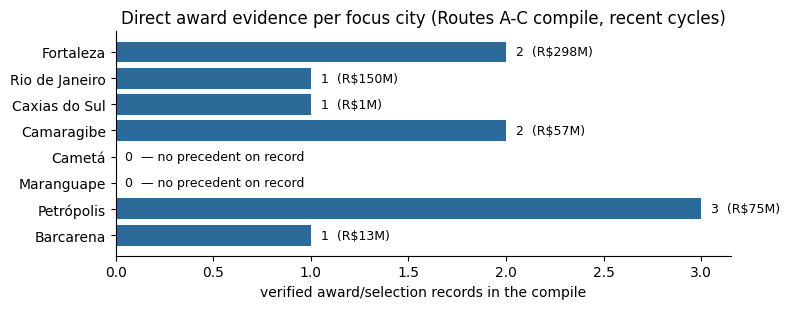

In [9]:
# Chart: award evidence available to each focus city
import matplotlib.pyplot as plt
city_ev = proj[proj["mun_norm"].isin(foc["mun_norm"].unique())].groupby("mun_norm").agg(
    n=("id", "count"), total=("amount_num", "sum"))
name_map = foc.drop_duplicates("mun_norm").set_index("mun_norm")["name"]
city_ev.index = city_ev.index.map(name_map)
city_ev = city_ev.reindex(FOCUS).fillna(0)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(city_ev.index[::-1], city_ev["n"][::-1], color="#2b6a99")
for i, (n, t) in enumerate(zip(city_ev["n"][::-1], city_ev["total"][::-1])):
    ax.text(n + 0.05, i, f"{int(n)}" + (f"  (R${t/1e6:,.0f}M)" if t else "  — no precedent on record"), va="center", fontsize=9)
ax.set_xlabel("verified award/selection records in the compile")
ax.set_title("Direct award evidence per focus city (Routes A-C compile, recent cycles)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [10]:
# Fit: the full read for one action in all eight cities — drainage cleaning (icare_0154)
view = foc[foc["action_id"].eq("icare_0154")][
    ["name", "capag", "finance_push_score", "finance_push_bucket", "funding_gap",
     "own_city_awards_matched", "state_matched_awards", "national_matched_median_brl"]]
view.sort_values("funding_gap").reset_index(drop=True)

,name,capag,finance_push_score,finance_push_bucket,funding_gap,own_city_awards_matched,state_matched_awards,national_matched_median_brl
0,Maranguape,C,9,established,needs_external_cofinance,0,8,32566719.0
1,Barcarena,n.d.,10,extensive,needs_external_cofinance,1,31,32566719.0
2,Cametá,C,9,established,needs_external_cofinance,0,31,32566719.0
3,Petrópolis,n.d.,11,extensive,needs_external_cofinance,1,20,32566719.0
4,Caxias do Sul,A+,9,established,own_budget_or_credit_feasible,0,13,32566719.0
5,Rio de Janeiro,B,11,extensive,own_budget_or_credit_feasible,1,20,32566719.0
6,Fortaleza,B+,11,extensive,own_budget_or_credit_feasible,1,8,32566719.0
7,Camaragibe,A+,8,established,own_budget_or_credit_feasible,0,9,32566719.0


In [11]:
# Fit: where evidence changes the story — cities whose bucket says co-finance AND a matched national pool exists
story = foc[foc["funding_gap"].str.contains("cofinance") & foc["national_matched_awards"].astype(int).gt(0)]
print(f"{len(story)} of {len(foc)} focus pairs are co-finance cases with a matched, proven national funding pool")
story.groupby("name").size().to_frame("actions_with_proven_pool")

152 of 424 focus pairs are co-finance cases with a matched, proven national funding pool


,actions_with_proven_pool
name,
Barcarena,38
Cametá,38
Maranguape,38
Petrópolis,38


## Findings

The evidence layer works as designed and the focus set tells the story compactly. The awarded cities show the route model is not hypothetical: Petrópolis holds three verified Novo PAC selections exactly matching its landslide/drainage action needs, Fortaleza holds both arms (a Novo PAC drainage selection and a COFIEX environment operation), and Caxias do Sul's slope-containment selection sits beside its A+ credit screen. The hard cases stay hard and honest: Cametá and Maranguape have no award record in the compile, so their co-finance buckets carry national comparables (median Novo PAC drainage selection R$32.6M, slope-containment R$8.6M) rather than local precedent. Camaragibe is the instructive outlier: a COFIEX urban-development operation on record alongside an A+ screen but the weakest finance-push score in the focus set — money routes open, formulation capacity binding. Two caveats travel with every row: the compile is staging (its category field is keyword-derived), and evidence covers Routes A-C recent cycles only, so "no precedent on record" means the compile, not Brazil.